In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor  # probably new to you
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from PIL import Image

## 01 Basics

In [ ]:
model_name = "Emiel/cub-200-bird-classifier-swin"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

In [128]:
root_path = '/mnt/ml/resources/wb2/CUB_200_2011/CUB_200_2011/images'
def sample_image(root: str = root_path, return_cls: bool = True):
    paths = list(Path(root).rglob('*.jpg'))
    rand_idx = np.random.choice(len(paths))
    
    path = paths[rand_idx]
    
    if return_cls:
        class_idx = int(path.parent.name[:3]) - 1
        return path, class_idx
    else:
        return path

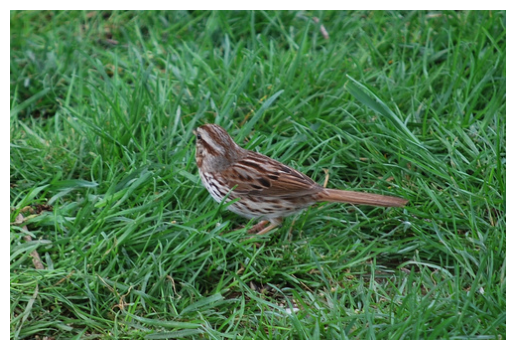

Predicted class: 128; true class: 128


In [40]:
path, class_idx = sample_image()

img = Image.open(path).convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.show()

inputs = processor(images=img, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    
print(f"Predicted class: {pred}; true class: {class_idx}")

## 02 Evaluation

In [68]:
from torch.utils.data import Dataset, DataLoader
from typing import Literal, Any
import pandas as pd
from tqdm import tqdm

In [92]:
class Cub200Dataset(Dataset):
    
    def __init__(self, path: str, split: Literal["train", "test"], processor) -> None:
        super().__init__()
        
        self.path = Path(path)
        self.split = split
        
        self.metadata = pd.read_csv(self.path / 'images.txt', sep=' ')
        self.metadata.columns = ['id', 'path']
        
        split_data = pd.read_csv(self.path / "train_test_split.txt", sep=' ')
        split_data.columns = ['id', 'is_train']
        
        self.metadata = pd.merge(self.metadata, split_data, on="id")
        if self.split == 'train':
            self.metadata = self.metadata[self.metadata['is_train'] == 1]
        else:
            self.metadata = self.metadata[self.metadata['is_train'] == 0]
        self.metadata.reset_index(drop=True, inplace=True)
        
        self.processor = processor
        
    def __len__(self) -> int:
        return self.metadata.shape[0]
    
    def __getitem__(self, index) -> Any:
        path = self.metadata.loc[index]['path']
        img = Image.open(str(self.path / 'images' / path)).convert('RGB')
        inputs = processor(images=img, return_tensors="pt")
        inputs['pixel_values'] = inputs['pixel_values'][0,:,:,:]
        class_idx = int(Path(path).parent.name[:3]) - 1
        return inputs, class_idx

In [ ]:
root_path = '/mnt/ml/resources/wb2/CUB_200_2011/CUB_200_2011'

dataset = Cub200Dataset(root_path, 'test', processor=processor)

inputs, label = dataset[500]
inputs

In [94]:
inputs['pixel_values'].shape

torch.Size([3, 384, 384])

In [ ]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

model.to('cuda')

ys = []
preds = []
with torch.no_grad():
    for idx, batch in enumerate(tqdm(dataloader)):
        X, y = batch
        X.to('cuda')
        y.to('cuda')
        
        logits = model(**X).logits
        pred = torch.argmax(logits, dim=-1)
        
        ys.append(y)
        preds.append(pred)
        
        if idx == 5:
            break

In [115]:
ys = torch.concat(ys).to('cpu')
preds = torch.concat(preds).to('cpu')

In [123]:
acc = (preds == ys).numpy().mean()
print(f"Accuracy estimated on subsample: {acc:.3f}")

Accuracy estimated on subsample: 0.901


## 03 CLIP

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

In [170]:
root_path = '/mnt/ml/resources/wb2/CelebA'
def sample_image(root: str = root_path, return_cls: bool = True):
    paths = list(Path(root).rglob('*.jpg'))
    rand_idx = np.random.choice(len(paths))
    
    path = paths[rand_idx]
    
    if return_cls:
        meta = pd.read_csv(Path(root) / "list_attr_celeba.txt", skiprows=1, sep=";")
        
        class_idx = meta[meta.iloc[:,0] == path.name]['Male'].iloc[0]
        return path, class_idx
    else:
        return path

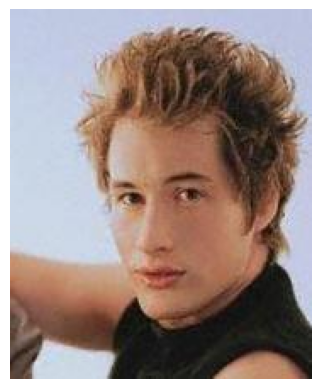

File name: /mnt/ml/resources/wb2/CelebA/img_align_celeba/124264.jpg
Model prediction 'is male': True; label: True
Similarity to Male: 0.22
Similarity to Female: 0.20


In [189]:
path, class_idx = sample_image("/mnt/ml/resources/wb2/CelebA", return_cls=True)

image = Image.open(path).convert("RGB")
plt.imshow(image)
plt.axis('off')
plt.show()

inputs_img = processor(images=image, return_tensors="pt")
inputs_text_male = processor(text="A photo of a Male", return_tensors="pt")
inputs_text_female = processor(text="A photo of a Female", return_tensors="pt")


with torch.no_grad():
    image_features = model.get_image_features(**inputs_img)['pooler_output']
    image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
    
    text_features_male = model.get_text_features(**inputs_text_male)['pooler_output']
    text_features_male = text_features_male / text_features_male.norm(p=2, dim=-1, keepdim=True)

    text_features_female = model.get_text_features(**inputs_text_female)['pooler_output']
    text_features_female = text_features_female / text_features_female.norm(p=2, dim=-1, keepdim=True)


male_similarity = torch.matmul(image_features, text_features_male.T)
female_similarity = torch.matmul(image_features, text_features_female.T)

is_male = (male_similarity > female_similarity).item()

print(f"File name: {path}")
print(f"Model prediction 'is male': {is_male}; label: {class_idx == 1}")
print(f"Similarity to Male: {male_similarity.item():.2f}")
print(f"Similarity to Female: {female_similarity.item():.2f}")

## 04 Next steps

Checking embedding of text and images has its disadvantages. First of all, you need to find the best prompt. Typically, "a photo of X" is fair enough, but we can do it better - namely, we can train a logistic regression **on top** of the CLIP's embedding. So let's try it!